# Hyperparameter Tuning (Optuna)

Tunes all three CatBoost models in `03a_CatBoost_and_Cox_Models.ipynb` (churn classifier, Tweedie forward-revenue regressor, Cox survival model) plus the ZILN neural-net forward-revenue challenger in `03c_ZILN_ForwardRevenue.ipynb` — none of which have had a search done on the current 27-feature set (8 features added on top of the original 19 — see `02_Feature_Engineering.ipynb`). This is an offline search notebook: its output (`results/optuna_best_params.json`) feeds back into `03a` and `03c`, each retrained once at full budget using the winning hyperparameters. This notebook is not part of the `00`→`06` run-in-order sequence.

The three CatBoost studies use reduced-iteration trials (`iterations=300`, `early_stopping_rounds=30`) to keep per-trial cost low — full 1000-iteration training isn't needed to *rank* hyperparameter configurations relative to each other, only the final production retrain needs the full budget. The ZILN study uses reduced-epoch trials (`max_epochs=15`, `patience=4`) for the same reason. Each study runs for a fixed wall-clock `timeout` rather than a fixed trial count, so total compute is bounded and predictable.

In [1]:
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
RESULTS_DIR = os.path.join(os.getcwd(), "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_train.parquet"))
val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
FEATURE_COLS = CAT_COLS + NUM_COLS

SEARCH_TIMEOUT_SECONDS = 1800  # 30 min per model (confirmed "thorough" budget)
TRIAL_ITERATIONS = 300         # reduced from the production 1000 - enough to rank configs
TRIAL_EARLY_STOPPING = 30

print(f"features: {len(FEATURE_COLS)}, train: {len(train_df):,}, val: {len(val_df):,}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


features: 27, train: 1,127,119, val: 241,526


## Churn classifier

Search space: `depth` (4-8), `learning_rate` (log-uniform 0.02-0.2), `l2_leaf_reg` (1-10), `bagging_temperature` (0-1), `random_strength` (log-uniform 1e-9-10). Maximizes validation AUC-ROC.

In [2]:
def churn_objective(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1e-9, 10.0, log=True),
    }
    model = CatBoostClassifier(
        iterations=TRIAL_ITERATIONS,
        loss_function="Logloss",
        eval_metric="AUC",
        cat_features=CAT_COLS,
        early_stopping_rounds=TRIAL_EARLY_STOPPING,
        random_seed=42,
        thread_count=4,
        verbose=False,
        **params,
    )
    model.fit(train_df[FEATURE_COLS], train_df["is_churn"], eval_set=(val_df[FEATURE_COLS], val_df["is_churn"]))
    return roc_auc_score(val_df["is_churn"], model.predict_proba(val_df[FEATURE_COLS])[:, 1])


def _churn_progress(study, trial):
    print(f"[churn] trial {trial.number:3d}  AUC={trial.value:.5f}  best={study.best_value:.5f}  "
          f"elapsed={time.time() - t0:.0f}s")


t0 = time.time()
churn_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
churn_study.optimize(churn_objective, timeout=SEARCH_TIMEOUT_SECONDS, callbacks=[_churn_progress])
print(f"\n{len(churn_study.trials)} trials in {time.time() - t0:.0f}s")
print(f"best AUC: {churn_study.best_value:.5f}")
print(f"best params: {churn_study.best_params}")

[churn] trial   0  AUC=0.95797  best=0.95797  elapsed=86s


[churn] trial   1  AUC=0.94221  best=0.95797  elapsed=157s


[churn] trial   2  AUC=0.95642  best=0.95797  elapsed=234s


[churn] trial   3  AUC=0.94750  best=0.95797  elapsed=340s


[churn] trial   4  AUC=0.95337  best=0.95797  elapsed=521s


...

[churn] trial  11  AUC=0.95775  best=0.95797  elapsed=1401s


[churn] trial  12  AUC=0.95683  best=0.95797  elapsed=1499s


[churn] trial  13  AUC=0.95599  best=0.95797  elapsed=1593s


[churn] trial  14  AUC=0.95821  best=0.95821  elapsed=1699s


[churn] trial  15  AUC=0.95755  best=0.95821  elapsed=1806s

16 trials in 1806s
best AUC: 0.95821
best params: {'depth': 6, 'learning_rate': 0.12355655587403722, 'l2_leaf_reg': 7.252785471204157, 'bagging_temperature': 0.274484973282481, 'random_strength': 0.0002490009866875922}


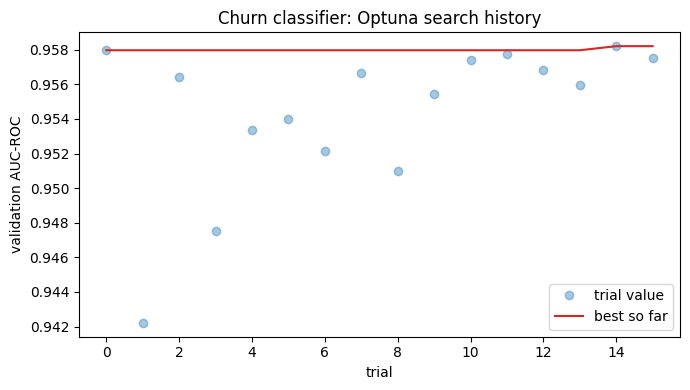

In [3]:
values = [t.value for t in churn_study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(values)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(values, "o", alpha=0.4, label="trial value")
ax.plot(best_so_far, color="tab:red", label="best so far")
ax.set_xlabel("trial")
ax.set_ylabel("validation AUC-ROC")
ax.set_title("Churn classifier: Optuna search history")
ax.legend()
fig.tight_layout()

## Forward-revenue regressor (Tweedie)

Same search space plus `variance_power` (1.1-1.9, Tweedie-specific). Minimizes validation RMSE on the raw `fwd_rev_59d` target — matching `03a`'s evaluation convention (the regressor predicts raw TWD directly, no `log1p`/`expm1`).

In [4]:
def fwd_rev_objective(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1e-9, 10.0, log=True),
    }
    variance_power = trial.suggest_float("variance_power", 1.1, 1.9)
    model = CatBoostRegressor(
        iterations=TRIAL_ITERATIONS,
        loss_function=f"Tweedie:variance_power={variance_power}",
        eval_metric="RMSE",
        cat_features=CAT_COLS,
        early_stopping_rounds=TRIAL_EARLY_STOPPING,
        random_seed=42,
        thread_count=4,
        verbose=False,
        **params,
    )
    model.fit(train_df[FEATURE_COLS], train_df["fwd_rev_59d"], eval_set=(val_df[FEATURE_COLS], val_df["fwd_rev_59d"]))
    pred = model.predict(val_df[FEATURE_COLS])
    return float(np.sqrt(np.mean((pred - val_df["fwd_rev_59d"].values) ** 2)))


def _fwd_rev_progress(study, trial):
    print(f"[fwd_rev] trial {trial.number:3d}  RMSE={trial.value:.3f}  best={study.best_value:.3f}  "
          f"elapsed={time.time() - t0:.0f}s")


t0 = time.time()
fwd_rev_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
fwd_rev_study.optimize(fwd_rev_objective, timeout=SEARCH_TIMEOUT_SECONDS, callbacks=[_fwd_rev_progress])
print(f"\n{len(fwd_rev_study.trials)} trials in {time.time() - t0:.0f}s")
print(f"best RMSE: {fwd_rev_study.best_value:.3f}")
print(f"best params: {fwd_rev_study.best_params}")

[fwd_rev] trial   0  RMSE=131.365  best=131.365  elapsed=64s


[fwd_rev] trial   1  RMSE=134.685  best=131.365  elapsed=120s


[fwd_rev] trial   2  RMSE=132.591  best=131.365  elapsed=228s


[fwd_rev] trial   3  RMSE=132.861  best=131.365  elapsed=302s


[fwd_rev] trial   4  RMSE=131.209  best=131.209  elapsed=382s


...

[fwd_rev] trial  15  RMSE=131.618  best=131.067  elapsed=1383s


[fwd_rev] trial  16  RMSE=130.690  best=130.690  elapsed=1504s


[fwd_rev] trial  17  RMSE=131.417  best=130.690  elapsed=1623s


[fwd_rev] trial  18  RMSE=131.097  best=130.690  elapsed=1744s


[fwd_rev] trial  19  RMSE=131.608  best=130.690  elapsed=1849s

20 trials in 1849s
best RMSE: 130.690
best params: {'depth': 8, 'learning_rate': 0.10529815068058854, 'l2_leaf_reg': 5.362153198694923, 'bagging_temperature': 0.004537534206282334, 'random_strength': 0.06993558647077869, 'variance_power': 1.2410989438322284}


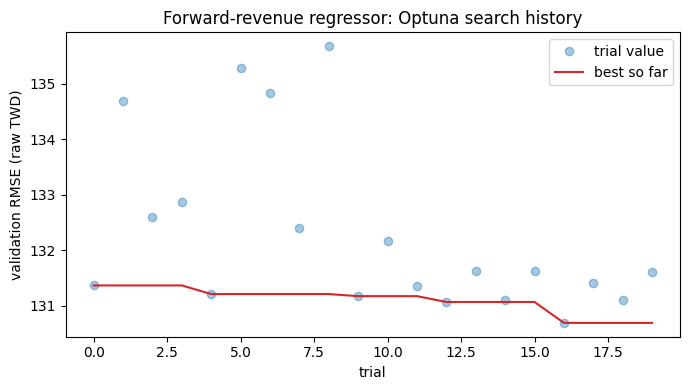

In [5]:
values = [t.value for t in fwd_rev_study.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(values, "o", alpha=0.4, label="trial value")
ax.plot(best_so_far, color="tab:red", label="best so far")
ax.set_xlabel("trial")
ax.set_ylabel("validation RMSE (raw TWD)")
ax.set_title("Forward-revenue regressor: Optuna search history")
ax.legend()
fig.tight_layout()

## Cox survival model

Rebuilds the same full censoring-inclusive population as `03a_CatBoost_and_Cox_Models.ipynb`'s Cox section (duplicated DuckDB query + train/val/test split, since that pipeline is notebook-inline in `03a`, not a `kkbox` package function — consistent with `03a`'s existing architecture rather than introducing a new abstraction just for this search). Search space: `depth`, `learning_rate`, `l2_leaf_reg`, `bagging_temperature`, `random_strength` (no `variance_power` - this isn't a Tweedie loss). Maximizes validation concordance index.

In [6]:
import duckdb
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

con = duckdb.connect()

con.execute(f"""
    create or replace temp table txn_cox as
    select *, strptime(cast(transaction_date as varchar), '%Y%m%d')::date as txn_dt,
           strptime(cast(membership_expire_date as varchar), '%Y%m%d')::date as expire_dt
    from '{os.path.join(PROCESSED_DIR, "transactions.parquet")}'
    where actual_amount_paid > 0
""")
con.execute("""
    create or replace temp table cox_ref as
    with valid_expiry as (
        select msno, expire_dt from txn_cox where expire_dt >= txn_dt
    )
    select t.msno, min(t.txn_dt) as start_dt, max(v.expire_dt) as ref_date,
           date_diff('day', min(t.txn_dt), max(v.expire_dt)) as duration_days,
           case when max(v.expire_dt) + interval 30 day <= date '2017-02-28' then 1 else 0 end as event_churned
    from txn_cox t
    join valid_expiry v using (msno)
    group by t.msno
""")

# Same 8 features added to 02_Feature_Engineering.ipynb (recency, most-recent-transaction
# snapshot, magnitude-based listening trend) - duplicated here since Cox rebuilds its own
# censoring-inclusive population rather than reading model_dataset's restricted one.
cox_query = f"""
    with txn_agg as (
        select t.msno, count(*) num_transactions,
               avg(t.payment_plan_days) avg_payment_plan_days,
               avg(t.actual_amount_paid) avg_actual_amount_paid,
               avg(t.is_auto_renew) is_auto_renew_rate
        from txn_cox t join cox_ref r using (msno)
        where t.txn_dt <= r.ref_date
        group by t.msno
    ),
    latest_txn as (
        select msno, payment_method_id, payment_plan_days as most_recent_payment_plan_days,
               actual_amount_paid as most_recent_actual_amount_paid,
               is_auto_renew as most_recent_is_auto_renew, is_cancel as most_recent_is_cancel
        from (
            select t.msno, t.payment_method_id, t.payment_plan_days, t.actual_amount_paid,
                   t.is_auto_renew, t.is_cancel,
                   row_number() over (partition by t.msno order by t.txn_dt desc) rn
            from txn_cox t join cox_ref r using (msno)
            where t.txn_dt <= r.ref_date
        ) where rn = 1
    ),
    last_login as (
        select l.msno, max(l.log_dt) as last_login_dt
        from (select *, strptime(cast(date as varchar), '%Y%m%d')::date as log_dt
              from '{os.path.join(PROCESSED_DIR, "user_logs.parquet")}') l
        join cox_ref r using (msno)
        where l.log_dt <= r.ref_date
        group by l.msno
    ),
    last_cancel as (
        select t.msno, max(t.txn_dt) as last_cancel_dt
        from txn_cox t join cox_ref r using (msno)
        where t.txn_dt <= r.ref_date and t.is_cancel = 1
        group by t.msno
    ),
    logs_agg as (
        select l.msno,
               count(distinct l.log_dt) daily_active_days,
               sum(greatest(least(l.total_secs, 86400), 0)) total_secs_sum,
               sum(l.num_25) sum25, sum(l.num_50) sum50, sum(l.num_75) sum75,
               sum(l.num_985) sum985, sum(l.num_100) sum100,
               sum(greatest(least(l.total_secs, 86400), 0))
                   filter (where l.log_dt >= r.ref_date - interval 6 day) as recent7_secs,
               sum(greatest(least(l.total_secs, 86400), 0))
                   filter (where l.log_dt < r.ref_date - interval 6 day) as prior23_secs,
               sum(l.num_unq) filter (where l.log_dt >= r.ref_date - interval 6 day) as recent7_numunq,
               sum(l.num_unq) filter (where l.log_dt < r.ref_date - interval 6 day) as prior23_numunq
        from (select *, strptime(cast(date as varchar), '%Y%m%d')::date as log_dt
              from '{os.path.join(PROCESSED_DIR, "user_logs.parquet")}') l
        join cox_ref r using (msno)
        where l.log_dt >= r.ref_date - interval 29 day and l.log_dt <= r.ref_date
        group by l.msno
    )
    select r.msno, r.ref_date, r.duration_days, r.event_churned,
           m.city, m.bd, m.gender, m.registered_via, m.registration_init_time,
           coalesce(txn_agg.num_transactions, 0) num_transactions,
           txn_agg.avg_payment_plan_days, txn_agg.avg_actual_amount_paid,
           coalesce(txn_agg.is_auto_renew_rate, 0) is_auto_renew_rate,
           latest_txn.payment_method_id,
           latest_txn.most_recent_payment_plan_days, latest_txn.most_recent_actual_amount_paid,
           coalesce(latest_txn.most_recent_is_auto_renew, 0) most_recent_is_auto_renew,
           coalesce(latest_txn.most_recent_is_cancel, 0) most_recent_is_cancel,
           date_diff('day', ll.last_login_dt, r.ref_date) as days_since_last_login,
           date_diff('day', lc.last_cancel_dt, r.ref_date) as days_since_last_cancel,
           coalesce(logs_agg.daily_active_days, 0) daily_active_days,
           coalesce(logs_agg.total_secs_sum, 0) total_secs_sum,
           coalesce(logs_agg.sum25,0) sum25, coalesce(logs_agg.sum50,0) sum50,
           coalesce(logs_agg.sum75,0) sum75, coalesce(logs_agg.sum985,0) sum985,
           coalesce(logs_agg.sum100,0) sum100,
           coalesce(logs_agg.recent7_secs, 0) recent7_secs, coalesce(logs_agg.prior23_secs, 0) prior23_secs,
           coalesce(logs_agg.recent7_numunq, 0) recent7_numunq, coalesce(logs_agg.prior23_numunq, 0) prior23_numunq
    from cox_ref r
    left join '{os.path.join(PROCESSED_DIR, "members.parquet")}' m using (msno)
    left join txn_agg using (msno)
    left join latest_txn using (msno)
    left join last_login ll using (msno)
    left join last_cancel lc using (msno)
    left join logs_agg using (msno)
"""
cox_df = con.execute(cox_query).df()

reg_date = pd.to_datetime(
    cox_df["registration_init_time"].astype("Int64").astype(str), format="%Y%m%d", errors="coerce"
)
cox_df["registration_tenure_days"] = (pd.to_datetime(cox_df["ref_date"]) - reg_date).dt.days
cox_df["gender"] = cox_df["gender"].fillna("unknown")
cox_df["city"] = cox_df["city"].fillna(-1).astype(int)
cox_df["registered_via"] = cox_df["registered_via"].fillna(-1).astype(int)
cox_df["bd_clean"] = cox_df["bd"].where(cox_df["bd"].between(1, 100))

song_totals = cox_df[["sum25", "sum50", "sum75", "sum985", "sum100"]].sum(axis=1)
cox_df["avg_song_completion"] = (
    0.25 * cox_df["sum25"] + 0.50 * cox_df["sum50"] + 0.75 * cox_df["sum75"]
    + 0.985 * cox_df["sum985"] + 1.0 * cox_df["sum100"]
) / (song_totals + 1)
cox_df["total_secs_log"] = np.log1p(cox_df["total_secs_sum"])
cox_df["secs_trend_recent_vs_prior"] = (cox_df["recent7_secs"] / 7.0) / ((cox_df["prior23_secs"] / 23.0) + 1)
cox_df["numunq_trend_recent_vs_prior"] = (cox_df["recent7_numunq"] / 7.0) / ((cox_df["prior23_numunq"] / 23.0) + 1)

COX_CAT_COLS = ["city", "gender", "registered_via", "payment_method_id"]
COX_NUM_COLS = [
    "bd_clean", "registration_tenure_days", "avg_payment_plan_days", "avg_actual_amount_paid",
    "num_transactions", "total_secs_log", "daily_active_days", "is_auto_renew_rate", "avg_song_completion",
    "days_since_last_login", "days_since_last_cancel",
    "secs_trend_recent_vs_prior", "numunq_trend_recent_vs_prior",
    "most_recent_payment_plan_days", "most_recent_actual_amount_paid",
    "most_recent_is_auto_renew", "most_recent_is_cancel",
]

cox_train, cox_temp = train_test_split(cox_df, test_size=0.30, stratify=cox_df["event_churned"], random_state=42)
cox_val, cox_test = train_test_split(cox_temp, test_size=0.50, stratify=cox_temp["event_churned"], random_state=42)
cox_splits = {"train": cox_train, "val": cox_val, "test": cox_test}

# Same imputation treatment as 02_Feature_Engineering.ipynb: median for lifetime/snapshot
# aggregates, sentinel (worse than any observed gap) for the recency features' legitimate
# never-happened population.
login_sentinel_cox = cox_train["days_since_last_login"].max() + 30
cancel_sentinel_cox = cox_train["days_since_last_cancel"].max() + 30
for col in [
    "bd_clean", "registration_tenure_days", "avg_payment_plan_days", "avg_actual_amount_paid",
    "most_recent_payment_plan_days", "most_recent_actual_amount_paid",
]:
    median = cox_train[col].median()
    for split in cox_splits.values():
        split[col] = split[col].fillna(median)
for split in cox_splits.values():
    split["days_since_last_login"] = split["days_since_last_login"].fillna(login_sentinel_cox)
    split["days_since_last_cancel"] = split["days_since_last_cancel"].fillna(cancel_sentinel_cox)

for split in cox_splits.values():
    signed_duration = split["duration_days"] + 0.5
    split["cox_target"] = np.where(split["event_churned"] == 1, signed_duration, -signed_duration)

print(f"cox population: {cox_df.shape}, train={len(cox_train):,}, val={len(cox_val):,}")

cox population: (1734274, 37), train=1,213,991, val=260,141


In [7]:
def cox_objective(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1e-9, 10.0, log=True),
    }
    model = CatBoostRegressor(
        iterations=TRIAL_ITERATIONS,
        loss_function="Cox",
        cat_features=COX_CAT_COLS,
        early_stopping_rounds=TRIAL_EARLY_STOPPING,
        random_seed=42,
        thread_count=4,
        verbose=False,
        **params,
    )
    model.fit(
        cox_train[COX_CAT_COLS + COX_NUM_COLS], cox_train["cox_target"],
        eval_set=(cox_val[COX_CAT_COLS + COX_NUM_COLS], cox_val["cox_target"]),
    )
    risk_score = model.predict(cox_val[COX_CAT_COLS + COX_NUM_COLS])
    return concordance_index(cox_val["duration_days"], -risk_score, cox_val["event_churned"])


def _cox_progress(study, trial):
    print(f"[cox] trial {trial.number:3d}  concordance={trial.value:.5f}  best={study.best_value:.5f}  "
          f"elapsed={time.time() - t0:.0f}s")


t0 = time.time()
cox_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
cox_study.optimize(cox_objective, timeout=SEARCH_TIMEOUT_SECONDS, callbacks=[_cox_progress])
print(f"\n{len(cox_study.trials)} trials in {time.time() - t0:.0f}s")
print(f"best concordance: {cox_study.best_value:.5f}")
print(f"best params: {cox_study.best_params}")

[cox] trial   0  concordance=0.95793  best=0.95793  elapsed=173s


[cox] trial   1  concordance=0.90589  best=0.95793  elapsed=319s


[cox] trial   2  concordance=0.95748  best=0.95793  elapsed=473s


[cox] trial   3  concordance=0.91242  best=0.95793  elapsed=620s


[cox] trial   4  concordance=0.92867  best=0.95793  elapsed=802s


...

[cox] trial   6  concordance=0.93509  best=0.95793  elapsed=1187s


[cox] trial   7  concordance=0.93855  best=0.95793  elapsed=1389s


[cox] trial   8  concordance=0.93013  best=0.95793  elapsed=1536s


[cox] trial   9  concordance=0.93555  best=0.95793  elapsed=1720s


[cox] trial  10  concordance=0.95669  best=0.95793  elapsed=1886s

11 trials in 1886s
best concordance: 0.95793
best params: {'depth': 5, 'learning_rate': 0.17854360608707254, 'l2_leaf_reg': 7.587945476302646, 'bagging_temperature': 0.5986584841970366, 'random_strength': 3.63233925694314e-08}


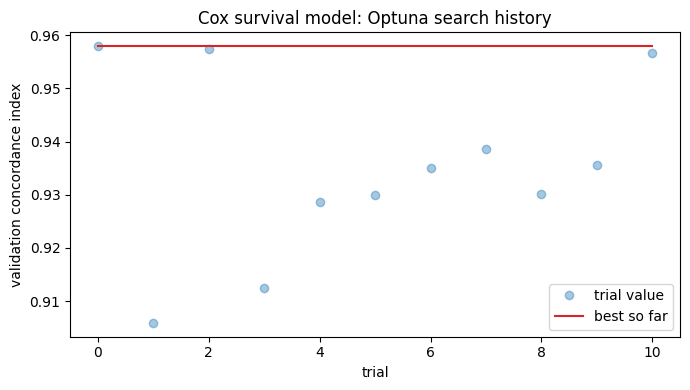

In [8]:
values = [t.value for t in cox_study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(values)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(values, "o", alpha=0.4, label="trial value")
ax.plot(best_so_far, color="tab:red", label="best so far")
ax.set_xlabel("trial")
ax.set_ylabel("validation concordance index")
ax.set_title("Cox survival model: Optuna search history")
ax.legend()
fig.tight_layout()

## ZILN neural net (forward-revenue challenger)

Tunes the `ZILNNet` architecture/training hyperparameters defined in `kkbox.ziln` — the neural-net challenger to the Tweedie forward-revenue regressor above, evaluated in `03c_ZILN_ForwardRevenue.ipynb`. Search space: `hidden_dim1`/`hidden_dim2` (network width), `dropout1`/`dropout2`, `learning_rate`, `weight_decay` (log-uniform), `batch_size`. The `mu`/`log_sigma` clamp ranges are **not** tuned — they're fixed based on the empirical distribution of `log(fwd_rev_59d)` among payers (mean=5.180, std=0.546), not architecture search; loosening them reintroduces the numerical instability documented in `kkbox.ziln`'s module docstring.

Each trial trains a single model with reduced epochs/patience (`max_epochs=15`, `patience=4`) — enough to rank configs, not to fully converge. Minimizes **validation RMSE** on the raw-TWD point estimate (matching the decision metric this search ultimately serves), not the proxy ZILN loss.

In [9]:
import torch

from kkbox.data import columns_from_manifest
from kkbox.ziln import train_one_model

ZILN_CAT_COLS, ZILN_NUM_COLS, CARDINALITIES, EMBED_DIMS = columns_from_manifest(manifest)
ZILN_TRIAL_MAX_EPOCHS = 15
ZILN_TRIAL_PATIENCE = 4


def ziln_objective(trial):
    hidden_dim1 = trial.suggest_int("hidden_dim1", 64, 256, step=32)
    hidden_dim2 = trial.suggest_int("hidden_dim2", 32, 128, step=16)
    dropout1 = trial.suggest_float("dropout1", 0.1, 0.5)
    dropout2 = trial.suggest_float("dropout2", 0.05, 0.3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [1024, 2048, 4096])

    torch.set_num_threads(4)
    _, _, val_rmse = train_one_model(
        train_df, val_df, ZILN_CAT_COLS, ZILN_NUM_COLS, CARDINALITIES, EMBED_DIMS,
        hidden_dim1=hidden_dim1, hidden_dim2=hidden_dim2, dropout1=dropout1, dropout2=dropout2,
        learning_rate=learning_rate, weight_decay=weight_decay, batch_size=batch_size,
        max_epochs=ZILN_TRIAL_MAX_EPOCHS, patience=ZILN_TRIAL_PATIENCE, seed=42, verbose=False,
    )
    return val_rmse


def _ziln_progress(study, trial):
    print(f"[ziln] trial {trial.number:3d}  RMSE={trial.value:.3f}  best={study.best_value:.3f}  "
          f"elapsed={time.time() - t0:.0f}s")


t0 = time.time()
ziln_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
ziln_study.optimize(ziln_objective, timeout=SEARCH_TIMEOUT_SECONDS, callbacks=[_ziln_progress])
print(f"\n{len(ziln_study.trials)} trials in {time.time() - t0:.0f}s")
print(f"best RMSE: {ziln_study.best_value:.3f}")
print(f"best params: {ziln_study.best_params}")

[ziln] trial   0  RMSE=423.082  best=423.082  elapsed=138s


[ziln] trial   1  RMSE=187.097  best=187.097  elapsed=282s


[ziln] trial   2  RMSE=134.776  best=134.776  elapsed=417s


[ziln] trial   3  RMSE=135.236  best=134.776  elapsed=558s


[ziln] trial   4  RMSE=139.645  best=134.776  elapsed=681s


...

[ziln] trial   8  RMSE=936.943  best=134.776  elapsed=1244s


[ziln] trial   9  RMSE=134.395  best=134.395  elapsed=1383s


[ziln] trial  10  RMSE=135.483  best=134.395  elapsed=1544s


[ziln] trial  11  RMSE=133.579  best=133.579  elapsed=1694s


[ziln] trial  12  RMSE=133.408  best=133.408  elapsed=1844s

13 trials in 1844s
best RMSE: 133.408
best params: {'hidden_dim1': 256, 'hidden_dim2': 64, 'dropout1': 0.21610737493812396, 'dropout2': 0.1321766045027286, 'learning_rate': 0.0009600461498177444, 'weight_decay': 0.0008792815436511888, 'batch_size': 2048}


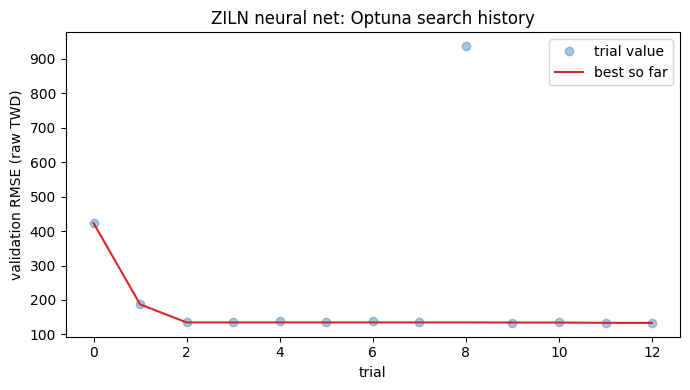

In [10]:
values = [t.value for t in ziln_study.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(values, "o", alpha=0.4, label="trial value")
ax.plot(best_so_far, color="tab:red", label="best so far")
ax.set_xlabel("trial")
ax.set_ylabel("validation RMSE (raw TWD)")
ax.set_title("ZILN neural net: Optuna search history")
ax.legend()
fig.tight_layout()

## Save best hyperparameters

Written to `results/optuna_best_params.json`, consumed by `03a_CatBoost_and_Cox_Models.ipynb`'s three model constructors for the final full-`iterations=1000` production retrain.

In [11]:
best_params = {
    "churn": churn_study.best_params,
    "fwd_rev": fwd_rev_study.best_params,
    "cox": cox_study.best_params,
    "ziln": ziln_study.best_params,
}
with open(os.path.join(RESULTS_DIR, "optuna_best_params.json"), "w") as f:
    json.dump(best_params, f, indent=2)

best_params

{'churn': {'depth': 6,
  'learning_rate': 0.12355655587403722,
  'l2_leaf_reg': 7.252785471204157,
  'bagging_temperature': 0.274484973282481,
  'random_strength': 0.0002490009866875922},
 'fwd_rev': {'depth': 8,
  'learning_rate': 0.10529815068058854,
  'l2_leaf_reg': 5.362153198694923,
  'bagging_temperature': 0.004537534206282334,
  'random_strength': 0.06993558647077869,
  'variance_power': 1.2410989438322284},
 'cox': {'depth': 5,
  'learning_rate': 0.17854360608707254,
  'l2_leaf_reg': 7.587945476302646,
  'bagging_temperature': 0.5986584841970366,
  'random_strength': 3.63233925694314e-08},
 'ziln': {'hidden_dim1': 256,
  'hidden_dim2': 64,
  'dropout1': 0.21610737493812396,
  'dropout2': 0.1321766045027286,
  'learning_rate': 0.0009600461498177444,
  'weight_decay': 0.0008792815436511888,
  'batch_size': 2048}}